## algorithm design and anlysis-2026 spring  homework 1 
**Deadline**：2026.5.20

**name**:


note：
---
1. 带有\*的题目，申请免上课的同学，必须完成，其他同学选作；
2. 请独立完成，如求助了他人或者大模型，请著明，并且不可省略算法分析部分；
4. 如若作答有雷同，全部取消成绩；
3. 需要书面作答的题目，可以通过引用图片的形式添加，但是注意上传项目时包含所引用的图片的源文件；
4. $log_n$ 默认表示$log_2{n}$;

## 问题 1

根据下列递归公式, 计算下列 $T(n)$ 对应的的渐近上界。要求所求的边界尽可能的紧（tight）, 请写明步骤。

1. $T(1)=1; T(n)=T(n/4)+1$ for $n>1$
2. $T(1)=1;T(n)=3T(n/3)+n^2$ for $n>1$
3. $T(1)=1;T(n)=T(2n/3)+1$ for $n>1$
4. $T(1)=1;T(n)=5T(n/4)+n$ for $n>1$
5. $T(n)=1 \ for\ n \le 2 ; T(n)=T(\sqrt{n})+1 \ for \ n>2$

answer:
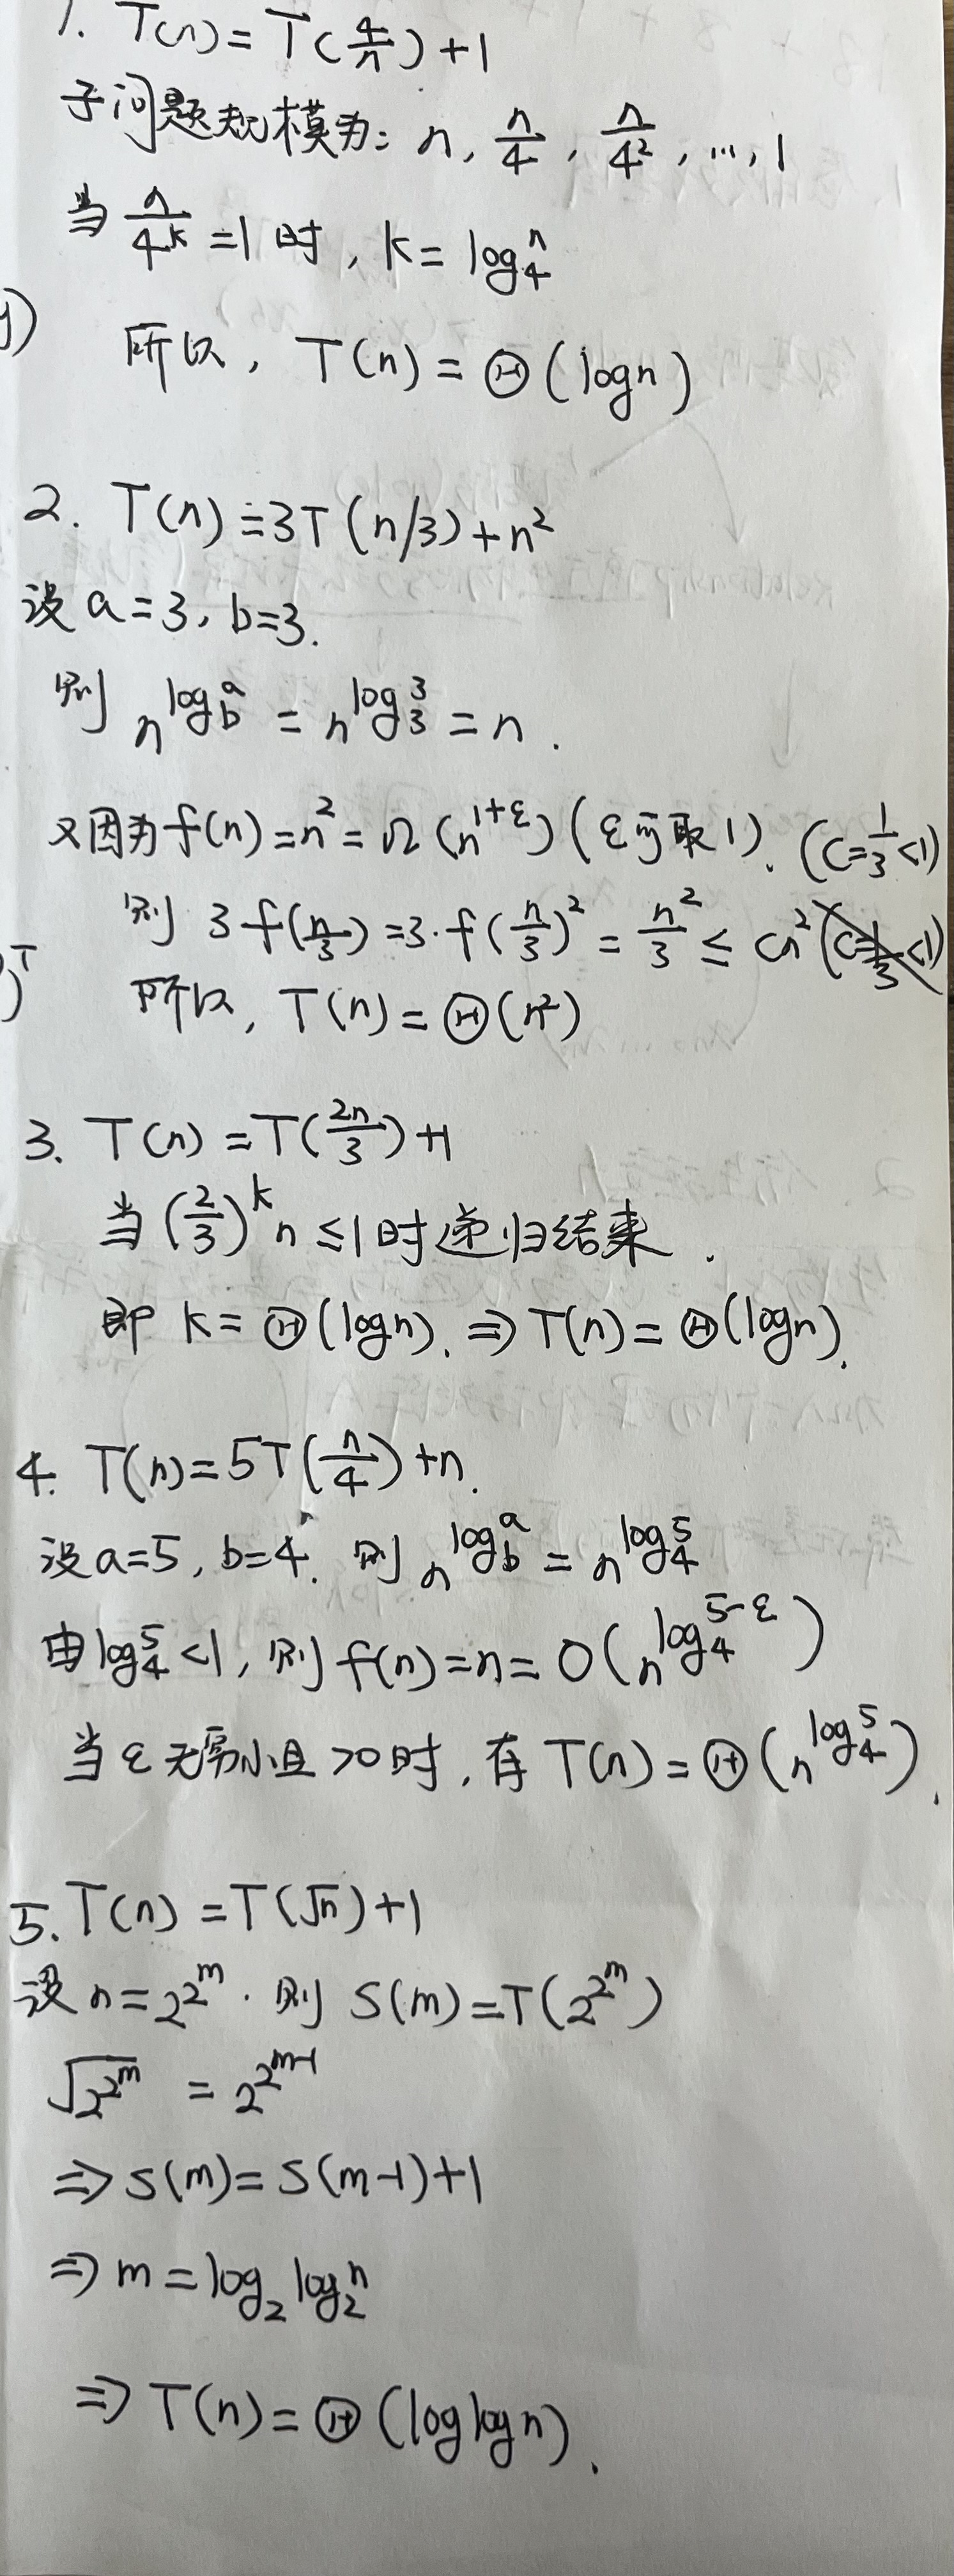



## 问题 2

观察下方的分治算法（divide-and-conquer algorithm）的伪代码, 回答下面问题

```latex
DoSomething(A,p,r)
-----
n := r-p+1
if n=2 and A[p]>A[r] then
    swap A[p] and A[r]
else if n >= 3 then
    m = ceil(2n/3)
    DoSomething(A,p,p+m-1)
    DoSomething(A,r-m+1,r)
    DoSomething(A,p,p+m-1)  
    
---
first call: DoSomething(A,1,n)
```

note：$ceil(2n/3)=\left\lceil {2n/3} \right\rceil$；$:=$ 表示赋值, 等价于 $\to$；A是一个包含n的整数元素的数组, 

1. 写出该算法时间复杂度的递归公式, 并求解其对应的渐进表示
2. 描述一下该算法的功能, 并判断是否是最高效的解决方案
3. \* 使用python编程实现上述算法或其对应的更高效版本的算法

算法分析：

1. 递归式为
   $$T(n)=3T(\lceil 2n/3 \rceil)+\Theta(1), \quad T(1)=T(2)=\Theta(1).$$
   用 Akra-Bazzi 方法，设 $3(2/3)^p=1$，得到
   $$p=\log_{3/2}3 \approx 2.7095.$$
   因为每层的额外代价只有常数，所以
   $$T(n)=\Theta(n^{\log_{3/2}3}).$$

In [ ]:
from math import ceil


def stooge_sort(arr, left=0, right=None):
    if right is None:
        right = len(arr) - 1
    if left >= right:
        return arr
    if right - left + 1 == 2 and arr[left] > arr[right]:
        arr[left], arr[right] = arr[right], arr[left]
    elif right - left + 1 >= 3:
        n = right - left + 1
        m = ceil(2 * n / 3)
        stooge_sort(arr, left, left + m - 1)
        stooge_sort(arr, right - m + 1, right)
        stooge_sort(arr, left, left + m - 1)
    return arr


def merge_sort(arr):
    if len(arr) <= 1:
        return arr[:]
    mid = len(arr) // 2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])
    merged = []
    i = j = 0
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            merged.append(left[i])
            i += 1
        else:
            merged.append(right[j])
            j += 1
    merged.extend(left[i:])
    merged.extend(right[j:])
    return merged


sample = [5, 2, 9, 1, 7, 3]
print("Stooge sort:", stooge_sort(sample[:]))
print("Merge sort :", merge_sort(sample))
print("Stooge sort time complexity: Theta(n^(log_{3/2} 3))")
print("Merge sort time complexity : Theta(n log n)")


Stooge sort: [1, 2, 3, 5, 7, 9]
Merge sort : [1, 2, 3, 5, 7, 9]
Stooge sort time complexity: Theta(n^(log_{3/2} 3))
Merge sort time complexity : Theta(n log n)


## 问题 3

给定一个包含n个元素的数组 `profits` , 它的第 `i` 个元素 `profits[i]` 表示一支股票第 `i` 天的**收益**（正数表示涨, 负数表示跌）。你只能选择 **某一天** 买入这只股票, 并选择在 **未来的某一个不同的日子** 卖出该股票。

1. 设计一个算法来计算你所能获取的最大利润和对应买入和卖出的日期。请分析算法方案, 计算其时间复杂度, 并且使用python编程实现该算法。

2. \* 设计一个时间复杂度为 $O(n)$的算法实现该算法

e.g. :
---
profits=[3,2,1,-7,5,2,-1,3,-1], 第5天买入, 第8天卖出, 收益最大：9

算法分析：

把 `profits[i]` 看成“从第 $i$ 天持有到第 $i+1$ 天结束所获得的收益”，那么从某一天买入并在未来某一天卖出，就等价于在数组中找一个元素和最大的连续子数组。
枚举买入日和卖出日，再用前缀和在 $O(1)$ 时间算出这段区间收益，总复杂度为 $O(n^2)$。

In [2]:
from itertools import accumulate


def max_profit_quadratic(profits):
    prefix = [0] + list(accumulate(profits))
    best_sum = profits[0]
    best_buy = best_sell = 1
    n = len(profits)
    for buy in range(n):
        for sell in range(buy, n):
            current = prefix[sell + 1] - prefix[buy]
            if current > best_sum:
                best_sum = current
                best_buy = buy + 1
                best_sell = sell + 1
    return best_sum, best_buy, best_sell


def max_profit_linear(profits):
    best_sum = current_sum = profits[0]
    best_buy = best_sell = 1
    current_start = 1

    for day in range(2, len(profits) + 1):
        value = profits[day - 1]
        if current_sum + value < value:
            current_sum = value
            current_start = day
        else:
            current_sum += value

        if current_sum > best_sum:
            best_sum = current_sum
            best_buy = current_start
            best_sell = day

    return best_sum, best_buy, best_sell


profits = [3, 2, 1, -7, 5, 2, -1, 3, -1]
print("Quadratic solution:", max_profit_quadratic(profits))
print("Linear solution   :", max_profit_linear(profits))
print("Time complexity of quadratic solution: O(n^2)")
print("Time complexity of linear solution   : O(n)")


Quadratic solution: (9, 5, 8)
Linear solution   : (9, 5, 8)
Time complexity of quadratic solution: O(n^2)
Time complexity of linear solution   : O(n)


## 问题 4

给定一个包含不同整数元素的数组 $ A[1..n]$ ,并且满足条件：$A[1]>A[2]$ 并且 $A[n-1]<A[n]$; 规定：如果一个元素比它两边的邻居元素都小, 即：$A[x]<A[x-1], A[x]<A[x+1]$ , 称这个元素A[x]为“局部最小”。通过遍历一次数组, 我们可以很容易在 $O(n)$的时间复杂度下找到一个局部最小值, 


1. 分析该问题, 设计一个算法在$O(logn)$的时间复杂度下找到一个局部最小(返回数值), 要求：分析算法设计思路, 并且使用python编程实现
2. \* 设计算法找出所有局部最小值, 分析算法设计思路, 并使用python编程实现

e.g.:
---
A=[9, 3, 7, 2, 1, 4, 5 ] 时,  局部最小元素为 3, 1

算法分析：

1. 题目给出 $A[1]>A[2]$ 和 $A[n-1]<A[n]$，这保证了数组内部至少存在一个局部最小值。
2. 设中点为 `mid`：如果 `A[mid] < A[mid-1]` 且 `A[mid] < A[mid+1]`，那么它就是一个局部最小;如果 `A[mid] > A[mid-1]`，说明左边一定存在局部最小，可以把搜索区间缩到左半边;否则必有 `A[mid] > A[mid+1]`，说明右边一定存在局部最小，可以把搜索区间缩到右半边。
3. 每次都把搜索区间缩小一半，因此找到一个局部最小的时间复杂度为 $O(\log n)$。
4. 如果要找出所有局部最小值，就不能只走一条分支。最直接的方法是线性扫描所有内部位置，时间复杂度为 $O(n)$。


In [3]:
def find_one_local_min(arr):
    left, right = 1, len(arr) - 2
    while left <= right:
        mid = (left + right) // 2
        if arr[mid] < arr[mid - 1] and arr[mid] < arr[mid + 1]:
            return arr[mid]
        if arr[mid] > arr[mid - 1]:
            right = mid - 1
        else:
            left = mid + 1
    raise ValueError("Input does not satisfy the problem constraints.")


def find_all_local_mins(arr):
    result = []
    for i in range(1, len(arr) - 1):
        if arr[i] < arr[i - 1] and arr[i] < arr[i + 1]:
            result.append(arr[i])
    return result


A = [9, 3, 7, 2, 1, 4, 5]
print("One local minimum :", find_one_local_min(A))
print("All local minima  :", find_all_local_mins(A))
print("Time complexity for one local minimum : O(log n)")
print("Time complexity for all local minima  : O(n)")


One local minimum : 1
All local minima  : [3, 1]
Time complexity for one local minimum : O(log n)
Time complexity for all local minima  : O(n)


## 问题 5

给定包含n个不同数字的一组数, 寻找一种基于比较的算法在这组数中找到k个最小的数字, 并按顺序输出它们。

1. 将n个数先进行排序, 然后按顺序输出最小的k个数。要求：选择合适的排序算法实现上述操作, 计算算法时间复杂度, 并使用python编程实现。
2. 建立一个包含这n个数的堆（heap）, 并且调用 k 次Extract-min 按顺序输出最小的k个数。使用往空堆中不断插入元素的方法建立堆, 分析这种方法建堆的时间复杂度, 并使用python编程实现
3. \* 假设数组中包含的数据总数目超过了计算机的存储能力, 请设计一个算法, 找到这堆数据的前k小的数值, 计算时间复杂度, 并使用python实现该算法, 假设计算机一定能存储k个数据。

e.g.：
---
数组arr=[5,4,3,2,6,1,88,33,22,107] 的前3个最小数据为：1, 2, 3

算法分析：

1. 方法一：先排序，再输出前 $k$ 个。若使用归并排序，则排序时间复杂度为 $O(n\log n)$，取前 $k$ 个只需 $O(k)$，总复杂度为 $O(n\log n)$。
2. 方法二：从空堆开始，逐个插入 $n$ 个元素建立最小堆。每次插入代价是 $O(\log n)$ 量级，所以这种建堆方式总复杂度为 $O(n\log n)$；之后执行 $k$ 次 `extract-min`，总代价为 $O(k\log n)$。
3. 当数据总量大于内存时，可以把数据看成数据流，只维护一个大小为 $k$ 的最大堆：先读入前 $k$ 个元素建堆；对后续每个元素，若它比堆顶更小，就替换堆顶；最终堆中保留的就是全体数据中最小的 $k$ 个数。
这种方法的时间复杂度为 $O(n\log k)$，空间复杂度为 $O(k)$。


In [4]:
import heapq


def merge_sort(arr):
    if len(arr) <= 1:
        return arr[:]
    mid = len(arr) // 2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])
    result = []
    i = j = 0
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1
    result.extend(left[i:])
    result.extend(right[j:])
    return result


def smallest_k_by_sort(arr, k):
    return merge_sort(arr)[:k]


def build_min_heap_by_insert(arr):
    heap = []
    for value in arr:
        heapq.heappush(heap, value)
    return heap


def smallest_k_by_heap(arr, k):
    heap = build_min_heap_by_insert(arr)
    return [heapq.heappop(heap) for _ in range(min(k, len(heap)))]


def smallest_k_stream(stream, k):
    max_heap = []
    for value in stream:
        if len(max_heap) < k:
            heapq.heappush(max_heap, -value)
        elif value < -max_heap[0]:
            heapq.heapreplace(max_heap, -value)
    return sorted(-value for value in max_heap)


arr = [5, 4, 3, 2, 6, 1, 88, 33, 22, 107]
k = 3
print("By sorting:", smallest_k_by_sort(arr, k))
print("By min-heap:", smallest_k_by_heap(arr, k))
print("By streaming max-heap:", smallest_k_stream(arr, k))
print("Sort-first complexity       : O(n log n)")
print("Insert-build heap complexity: O(n log n), plus O(k log n) extraction")
print("Streaming complexity        : O(n log k), space O(k)")


By sorting: [1, 2, 3]
By min-heap: [1, 2, 3]
By streaming max-heap: [1, 2, 3]
Sort-first complexity       : O(n log n)
Insert-build heap complexity: O(n log n), plus O(k log n) extraction
Streaming complexity        : O(n log k), space O(k)


## 问题 6

> 星球碰撞问题：现有n个星球，在同一条直线上运行，如数组A所示，元素的绝对值表示星球的质量，负数表示星球自右向左运动，正数表示星球自左向右运动，当两个星球相撞的时候，质量小的会消失，大的保持不变，**质量相同的两个星球碰撞后自右向左运动的星球消失，自左向右的星球保持不变**，假设所有星球的速度大小相同。
>
> $ A=[23,-8, 9, -3, -7, 9, -23, 22] $

请设计一个算法模拟星球的运行情况，输出最终的星球存续情况（输出一个数组），分析算法设计思路，计算时间复杂度，并基于python编程实现。

e.g.
---
1.  输入： A=[-3,-6,2,8, 5,-8,9,-2,1]， 输出：[-3, -6, 2, 8, 9, 1]

2. 输入：A=[23,-8, 9, -3, -7, 9, -23, 22], 输出：[23, 22]

算法分析：

1. 如果当前星球向右运动（正数），它暂时不会和左边星球碰撞，直接入栈。
2. 如果当前星球向左运动（负数），只有当栈顶是向右运动的正数时才可能发生碰撞。
3. 不断比较二者质量：若栈顶质量更小，则栈顶消失，当前星球继续和新的栈顶比较；若栈顶质量更大，则当前星球消失；若质量相同，根据题目规则，向左运动的当前星球消失，向右运动的栈顶保留。
4. 每个元素最多入栈、出栈一次，因此总时间复杂度为 $O(n)$。


In [5]:
def asteroid_collision(planets):
    stack = []
    for planet in planets:
        alive = True
        while alive and planet < 0 and stack and stack[-1] > 0:
            if stack[-1] < -planet:
                stack.pop()
            elif stack[-1] == -planet:
                alive = False
            else:
                alive = False
        if alive:
            stack.append(planet)
    return stack


example1 = [-3, -6, 2, 8, 5, -8, 9, -2, 1]
example2 = [23, -8, 9, -3, -7, 9, -23, 22]
print("Example 1:", asteroid_collision(example1))
print("Example 2:", asteroid_collision(example2))
print("Time complexity: O(n)")


Example 1: [-3, -6, 2, 8, 9, 1]
Example 2: [23, 22]
Time complexity: O(n)


## 问题 7

> 0-1背包问题：现在有4块大理石，每个大理石对应的重量和价值使用一个元组表示, 即（重量，价值），4块大理石的重量和价值为：[(5,10), (4,40), (6,30), (3, 50)], 假设你有一辆最大承重为9的小推车，请问使用这个小推车装大理石的最大价值为多少

请设计一个算法解决该问题，分析算法设计思路，计算时间复杂度，并基于python编程实现

算法分析

设 `dp[i][w]` 表示“只考虑前 `i` 件物品、背包容量为 `w` 时的最大价值”，则有状态转移：

$$
dp[i][w]=
\begin{cases}
dp[i-1][w], & w_i>w \\
\max\{dp[i-1][w],\ dp[i-1][w-w_i]+v_i\}, & w_i\le w
\end{cases}
$$

其中 $(w_i,v_i)$ 是第 `i` 件物品的重量和价值。共有 $n\times W$ 个状态，因此时间复杂度为 $O(nW)$，空间复杂度也为 $O(nW)$。如果只要求最大价值，还可以进一步压缩为一维动态规划。


In [6]:
def knapsack_01(items, capacity):
    n = len(items)
    dp = [[0] * (capacity + 1) for _ in range(n + 1)]

    for i in range(1, n + 1):
        weight, value = items[i - 1]
        for w in range(capacity + 1):
            dp[i][w] = dp[i - 1][w]
            if weight <= w:
                dp[i][w] = max(dp[i][w], dp[i - 1][w - weight] + value)

    chosen = []
    w = capacity
    for i in range(n, 0, -1):
        if dp[i][w] != dp[i - 1][w]:
            chosen.append(items[i - 1])
            w -= items[i - 1][0]
    chosen.reverse()
    return dp[n][capacity], chosen


items = [(5, 10), (4, 40), (6, 30), (3, 50)]
capacity = 9
best_value, chosen_items = knapsack_01(items, capacity)
print("Maximum value:", best_value)
print("Chosen items :", chosen_items)
print("Time complexity: O(nW)")


Maximum value: 90
Chosen items : [(4, 40), (3, 50)]
Time complexity: O(nW)


## 问题 8

给你二叉搜索树的根节点 root ，该树中的恰好两个节点的值被错误地交换。请在不改变其结构的情况下，恢复这棵树 。设计算法解决该问题，分析算法设计思路，计算时间复杂度，并基于python编程实现

e.g.:
---
1.

<div style="text-align:center;width:200px;"> <img alt="" src="./fig/hw3q9-1.jpg"> </div>
输入：root = [1,3,null,null,2]， 输出为：[3,1,null,null,2]， 

解释：3 不能是 1 的左孩子，因为 3 > 1 。交换 1 和 3 使二叉搜索树有效。

2.

 <div style="text-align:center;width:200px;"> <img alt="" src="./fig/hw3q9-1.jpg"> </div>
输入： root=[3,1,4,null,null,2]， 输出为：[2,1,4,null,null,3]

解释：2 不能在 3 的右子树中，因为 2 < 3 。交换 2 和 3 使二叉搜索树有效。

算法分析：

1. 对整棵树做中序遍历，并记录前一个访问到的节点 `prev`。
2. 一旦发现 `prev.val > current.val`，说明出现逆序：第一次逆序时，把 `first` 记为 `prev`； 每次逆序都把 `second` 记为 `current`。
3. 遍历结束后，交换 `first.val` 与 `second.val`，就能在不改变树结构的前提下恢复 BST。
每个节点只访问一次，所以时间复杂度为 $O(n)$；辅助栈深度为树高 $h$，空间复杂度为 $O(h)$。


In [7]:
from collections import deque


class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right


def build_tree(level_order):
    if not level_order or level_order[0] is None:
        return None
    root = TreeNode(level_order[0])
    queue = deque([root])
    i = 1
    while queue and i < len(level_order):
        node = queue.popleft()
        if i < len(level_order) and level_order[i] is not None:
            node.left = TreeNode(level_order[i])
            queue.append(node.left)
        i += 1
        if i < len(level_order) and level_order[i] is not None:
            node.right = TreeNode(level_order[i])
            queue.append(node.right)
        i += 1
    return root


def serialize_level_order(root):
    if not root:
        return []
    result = []
    queue = deque([root])
    while queue:
        node = queue.popleft()
        if node is None:
            result.append(None)
            continue
        result.append(node.val)
        queue.append(node.left)
        queue.append(node.right)
    while result and result[-1] is None:
        result.pop()
    return result


def recover_bst(root):
    stack = []
    current = root
    prev = first = second = None

    while stack or current:
        while current:
            stack.append(current)
            current = current.left
        current = stack.pop()
        if prev and prev.val > current.val:
            if first is None:
                first = prev
            second = current
        prev = current
        current = current.right

    if first and second:
        first.val, second.val = second.val, first.val
    return root


root1 = build_tree([1, 3, None, None, 2])
recover_bst(root1)
print("Example 1:", serialize_level_order(root1))

root2 = build_tree([3, 1, 4, None, None, 2])
recover_bst(root2)
print("Example 2:", serialize_level_order(root2))
print("Time complexity: O(n), space complexity: O(h)")


Example 1: [3, 1, None, None, 2]
Example 2: [2, 1, 4, None, None, 3]
Time complexity: O(n), space complexity: O(h)


## 问题 9 \*
给定 `n` 个非负整数表示每个宽度为 `1` 的柱子的高度图，计算按此排列的柱子，下雨之后能接多少雨水。



<div style="text-align:center;width:800px;"> <img alt="" src="./fig/hw3q6.png"> </div>

请分析算法设计思路，计算时间复杂度，并基于python编程实现

算法分析：

设左右指针分别为 `left` 和 `right`，并维护两侧目前见过的最高柱子 `left_max` 与 `right_max`。
1. 如果 `height[left] <= height[right]`，说明当前位置左边的装水高度由 `left_max` 决定： 若 `height[left] < left_max`，则当前位置可以接 `left_max-height[left]` 的水；否则更新 `left_max`。
2. 否则，对右侧做对称处理。
3. 每个位置只访问一次，因此时间复杂度为 $O(n)$，额外空间复杂度为 $O(1)$。


In [8]:
def trap_rain_water(height):
    left, right = 0, len(height) - 1
    left_max = right_max = 0
    water = 0

    while left <= right:
        if height[left] <= height[right]:
            if height[left] >= left_max:
                left_max = height[left]
            else:
                water += left_max - height[left]
            left += 1
        else:
            if height[right] >= right_max:
                right_max = height[right]
            else:
                water += right_max - height[right]
            right -= 1
    return water


height = [0, 1, 0, 2, 1, 0, 1, 3, 2, 1, 2, 1]
print("Trapped water:", trap_rain_water(height))
print("Time complexity: O(n), space complexity: O(1)")


Trapped water: 6
Time complexity: O(n), space complexity: O(1)


## 问题 10

给你一个二叉树的根节点 root ，树中每个节点都存放有一个 0 到 9 之间的数字。每条从根节点到叶节点的路径都代表一个数字：

> 例如，从根节点到叶节点的路径 1 -> 2 -> 3 表示数字 123 。

设计一个算法计算从根节点到叶节点生成的所有数字之和 ，分析算法设计思路，计算时间复杂度，并基于python编程实现

叶节点:是指没有子节点的节点。

e.g.:
---
1.

 <div style="text-align:center;width:200px;"> <img alt="figure" src="./fig/hw3q10-1.jpg"> </div>

 输入：root = [1,2,3], 输出：25

解释：从根到叶子节点路径 1->2 代表数字 12，1->3 代表数字 13，因此和为 12 + 13 = 25 。

2.

 <div style="text-align:center;width:200px;"> <img alt="figure" src="./fig/hw3q10-2.jpg"> </div>

 输入：root = [4,9,0,5,1], 输出：1026

解释：从根到叶子节点路径 4->9->5 代表数字 495，4->9->1 代表数字 491，4->0 代表数字 40。因此和为 495 + 491 + 40 = 1026 。

算法分析：

遍历到一个节点时，把当前路径形成的数字更新为
$$
\text{current}=\text{current}\times 10 + node.val.
$$

1. 如果当前节点是叶节点，那么这条路径对应的数字已经完整形成，直接返回它。
2. 否则递归计算左子树和右子树产生的数字之和。
3. 每个节点只访问一次，所以时间复杂度为 $O(n)$，递归栈空间复杂度为 $O(h)$。


In [9]:
from collections import deque


class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right


def build_tree(level_order):
    if not level_order or level_order[0] is None:
        return None
    root = TreeNode(level_order[0])
    queue = deque([root])
    i = 1
    while queue and i < len(level_order):
        node = queue.popleft()
        if i < len(level_order) and level_order[i] is not None:
            node.left = TreeNode(level_order[i])
            queue.append(node.left)
        i += 1
        if i < len(level_order) and level_order[i] is not None:
            node.right = TreeNode(level_order[i])
            queue.append(node.right)
        i += 1
    return root


def sum_root_to_leaf_numbers(root):
    def dfs(node, current):
        if node is None:
            return 0
        current = current * 10 + node.val
        if node.left is None and node.right is None:
            return current
        return dfs(node.left, current) + dfs(node.right, current)

    return dfs(root, 0)


root1 = build_tree([1, 2, 3])
root2 = build_tree([4, 9, 0, 5, 1])
print("Example 1:", sum_root_to_leaf_numbers(root1))
print("Example 2:", sum_root_to_leaf_numbers(root2))
print("Time complexity: O(n), space complexity: O(h)")


Example 1: 25
Example 2: 1026
Time complexity: O(n), space complexity: O(h)
